# PET-PINN Adaptation — 1D Counter-Flow Heat Exchanger
**Applied ML for Scientists & Engineers — Final Project (Ehud Ischakbaev & Daniel Azouri)**

**Anchor paper:** Fu, W., Wang, H., and Wang, J., *"Efficient adaptation of physics-informed neural networks for parametric thermal convection using adapter layers,"* Appl. Phys. Lett. **128**, 083901 (2026).

We reproduce the paper's central comparison — **adapter-based fine-tuning (PET-PINN) vs. full fine-tuning** — on a reduced, fully controlled system: the 1D counter-flow heat exchanger, whose exact analytical solution provides ground truth at **every** operating point $(k_h, k_c)$.

$$\frac{dT_h}{dx} = -k_h(T_h - T_c), \qquad \frac{dT_c}{dx} = -k_c(T_h - T_c), \qquad T_h(0)=100\,^\circ\mathrm{C},\; T_c(L)=20\,^\circ\mathrm{C}$$

**Experiment (mirrors Table I of Fu et al.):**
1. **Pre-train** a baseline PINN at the source point $(k_h,k_c)=(1.0,1.0)$.
2. **Adapt** to the target $(2.0, 0.8)$ three ways: (a) from scratch [reference], (b) full fine-tuning, (c) frozen backbone + rank-$r$ adapters.
3. **Compare:** relative $L_2$ error vs. the closed-form solution, trainable-parameter count, wall-clock time.

Note: implemented in **pure PyTorch** (not DeepXDE) — selective layer freezing and adapter injection require direct control of the module graph.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# 0. Reproducibility & problem constants
# ----------------------------------------------------------------------------
SEED = 2026
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

L = 1.0
T_H_IN, T_C_IN = 100.0, 20.0
T_REF, T_SPAN = T_C_IN, (T_H_IN - T_C_IN)

SOURCE = (1.0, 1.0)      # pre-training operating point
TARGET = (2.0, 0.8)      # adaptation target

N_COL = 100              # collocation points
PRETRAIN_ADAM = 10000
ADAPT_ADAM = 3000        # same Adam budget for full-FT and adapters
ADAM_LR = 1e-3
ADAPTER_RANK = 4         # r=4 as in Fu et al.

## Analytical ground truth
$\Delta T = T_h - T_c$ obeys $\Delta T(x) = D_0 e^{-\lambda x}$ with $\lambda = k_h - k_c$; $D_0$ follows from the boundary conditions. Valid for **any** $(k_h,k_c)$ — exact reference at every adaptation target.

In [2]:
def analytical_solution(x, k_h, k_c):
    """Exact solution with T_h(0)=T_H_IN, T_c(L)=T_C_IN."""
    x = np.asarray(x, dtype=float)
    lam = k_h - k_c
    dT_in = T_H_IN - T_C_IN
    if np.isclose(lam, 0.0):
        D0 = dT_in / (1.0 + k_h * L)
        T_h = T_H_IN - k_h * D0 * x
        dT = D0 * np.ones_like(x)
    else:
        denom = k_h * (1.0 - np.exp(-lam * L)) / lam + np.exp(-lam * L)
        D0 = dT_in / denom
        T_h = T_H_IN - k_h * D0 * (1.0 - np.exp(-lam * x)) / lam
        dT = D0 * np.exp(-lam * x)
    return T_h, T_h - dT


def relative_l2(pred, exact):
    return np.linalg.norm(pred - exact) / np.linalg.norm(exact)


# ----------------------------------------------------------------------------
# 1. Models

## Models

- **`BasePINN`** — same architecture as our verified DeepXDE baseline: $[1] + 3\times[20] + [2]$, tanh, output transform to the physical temperature range.
- **`Adapter`** — bottleneck module, Eq. (2) of Fu et al.: $h' = h + W_{down}\,\sigma(W_{up} h)$ with rank $r=4$ (like LoRA). $W_{down}$ initialized to **zero**, so the adapted network starts exactly identical to the frozen backbone.
- **`AdaptedPINN`** — frozen backbone + one adapter after each hidden activation (Eq. (3) of Fu et al.). Only the adapters receive gradients.

In [3]:
class BasePINN(nn.Module):
    """FNN [1] + 3x[20] + [2], tanh, matching the DeepXDE baseline.
    Output transform rescales O(1) outputs to the physical range."""

    def __init__(self, width=20, depth=3):
        super().__init__()
        self.inp = nn.Linear(1, width)
        self.hidden = nn.ModuleList(
            [nn.Linear(width, width) for _ in range(depth - 1)])
        self.out = nn.Linear(width, 2)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def hidden_states(self, x):
        """Returns the post-activation hidden states h1..h_depth."""
        hs = [torch.tanh(self.inp(x))]
        for lin in self.hidden:
            hs.append(torch.tanh(lin(hs[-1])))
        return hs

    def forward(self, x):
        h = self.hidden_states(x)[-1]
        return T_REF + T_SPAN * self.out(h)


class Adapter(nn.Module):
    """Bottleneck adapter, Eq. (2) of Fu et al.:
    h' = h + W_down * sigma(W_up * h), r << d.
    W_down initialized to zero so the adapted network starts exactly
    equal to the frozen backbone (identity residual)."""

    def __init__(self, d=20, r=ADAPTER_RANK):
        super().__init__()
        self.up = nn.Linear(d, r)
        self.down = nn.Linear(r, d)
        nn.init.xavier_normal_(self.up.weight)
        nn.init.zeros_(self.up.bias)
        nn.init.zeros_(self.down.weight)   # identity start
        nn.init.zeros_(self.down.bias)
        self.act = nn.GELU()

    def forward(self, h):
        return h + self.down(self.act(self.up(h)))


class AdaptedPINN(nn.Module):
    """Frozen BasePINN backbone with one adapter after each hidden
    activation (Eq. (3) of Fu et al.). Only adapters are trainable."""

    def __init__(self, base: BasePINN, r=ADAPTER_RANK):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)
        d = base.inp.out_features
        n_hidden = 1 + len(base.hidden)
        self.adapters = nn.ModuleList([Adapter(d, r) for _ in range(n_hidden)])

    def forward(self, x):
        h = self.adapters[0](torch.tanh(self.base.inp(x)))
        for lin, ad in zip(self.base.hidden, self.adapters[1:]):
            h = ad(torch.tanh(lin(h)))
        return T_REF + T_SPAN * self.base.out(h)


def n_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Physics loss and training loop
Composite loss = mean squared ODE residuals at 100 collocation points + Dirichlet BC errors at the two inlets. Two-stage optimization: Adam followed by L-BFGS, applied **only to the trainable parameters** (crucial for the adapter case).

In [4]:
X_COL = torch.linspace(0.0, L, N_COL, device=DEVICE).reshape(-1, 1)
X0 = torch.zeros(1, 1, device=DEVICE)   # hot inlet
XL = torch.full((1, 1), L, device=DEVICE)  # cold inlet


def pinn_loss(model, k_h, k_c):
    x = X_COL.clone().requires_grad_(True)
    out = model(x)
    T_h, T_c = out[:, 0:1], out[:, 1:2]
    dTh = torch.autograd.grad(T_h, x, torch.ones_like(T_h), create_graph=True)[0]
    dTc = torch.autograd.grad(T_c, x, torch.ones_like(T_c), create_graph=True)[0]
    res_h = dTh + k_h * (T_h - T_c)
    res_c = dTc + k_c * (T_h - T_c)
    bc = ((model(X0)[:, 0] - T_H_IN) ** 2).mean() + \
         ((model(XL)[:, 1] - T_C_IN) ** 2).mean()
    return (res_h ** 2).mean() + (res_c ** 2).mean() + bc


def train(model, k_h, k_c, adam_iters, tag=""):
    """Adam then L-BFGS on the trainable parameters only.
    Returns (loss_history, wall_clock_seconds)."""
    params = [p for p in model.parameters() if p.requires_grad]
    t0 = time.time()
    history = []

    opt = torch.optim.Adam(params, lr=ADAM_LR)
    for it in range(adam_iters):
        opt.zero_grad()
        loss = pinn_loss(model, k_h, k_c)
        loss.backward()
        opt.step()
        if it % 100 == 0 or it == adam_iters - 1:
            history.append((it, loss.item()))

    lbfgs = torch.optim.LBFGS(params, max_iter=500, history_size=50,
                              tolerance_grad=1e-12, tolerance_change=1e-14,
                              line_search_fn="strong_wolfe")

    def closure():
        lbfgs.zero_grad()
        loss = pinn_loss(model, k_h, k_c)
        loss.backward()
        return loss

    lbfgs.step(closure)
    wall = time.time() - t0
    final = pinn_loss(model, k_h, k_c).item()
    history.append((adam_iters, final))
    print(f"[{tag}] final loss {final:.3e}   wall {wall:.1f}s   "
          f"trainable params {n_trainable(model)}")
    return history, wall


def evaluate(model, k_h, k_c, n=200):
    x = np.linspace(0.0, L, n).reshape(-1, 1)
    with torch.no_grad():
        pred = model(torch.tensor(x, device=DEVICE)).cpu().numpy()
    Th_e, Tc_e = analytical_solution(x.ravel(), k_h, k_c)
    return (relative_l2(pred[:, 0], Th_e), relative_l2(pred[:, 1], Tc_e),
            x, pred, Th_e, Tc_e)

## Run the full experiment

In [5]:
def main():
    results = []

    # --- Stage 1: pre-train baseline at SOURCE ---
    print(f"\n=== Pre-training at source (k_h,k_c)={SOURCE} ===")
    base = BasePINN().to(DEVICE)
    _, wall_pre = train(base, *SOURCE, PRETRAIN_ADAM, tag="pretrain")
    eh, ec, *_ = evaluate(base, *SOURCE)
    print(f"    source rel L2: T_h {eh:.2e}, T_c {ec:.2e}")

    # sanity: pre-trained model evaluated at TARGET (no adaptation)
    eh0, ec0, *_ = evaluate(base, *TARGET)
    print(f"    UNADAPTED error at target: T_h {eh0:.2e}, T_c {ec0:.2e}")
    results.append(("No adaptation", 0, 0.0, eh0, ec0))

    # --- Method A: from scratch at TARGET (reference) ---
    print(f"\n=== (a) From scratch at target {TARGET} ===")
    torch.manual_seed(SEED)
    scratch = BasePINN().to(DEVICE)
    _, wall_a = train(scratch, *TARGET, PRETRAIN_ADAM, tag="scratch")
    eh_a, ec_a, *_ = evaluate(scratch, *TARGET)
    results.append(("From scratch", n_trainable(scratch), wall_a, eh_a, ec_a))

    # --- Method B: full fine-tuning ---
    print(f"\n=== (b) Full fine-tuning ({ADAPT_ADAM} Adam iters) ===")
    import copy
    full_ft = copy.deepcopy(base)
    for p in full_ft.parameters():
        p.requires_grad_(True)
    _, wall_b = train(full_ft, *TARGET, ADAPT_ADAM, tag="full-FT")
    eh_b, ec_b, *_ = evaluate(full_ft, *TARGET)
    results.append(("Full fine-tuning", n_trainable(full_ft), wall_b, eh_b, ec_b))

    # --- Method C: adapters (PET-PINN) ---
    print(f"\n=== (c) Adapters, rank r={ADAPTER_RANK} ({ADAPT_ADAM} Adam iters) ===")
    pet = AdaptedPINN(copy.deepcopy(base)).to(DEVICE)
    _, wall_c = train(pet, *TARGET, ADAPT_ADAM, tag="adapters")
    eh_c, ec_c, x, pred, Th_e, Tc_e = evaluate(pet, *TARGET)
    results.append((f"Adapters (r={ADAPTER_RANK})", n_trainable(pet), wall_c, eh_c, ec_c))

    # --- Table I analogue ---
    print("\n" + "=" * 78)
    print(f"TABLE (source {SOURCE} -> target {TARGET}, seed {SEED}, {DEVICE})")
    print("=" * 78)
    print(f"{'Method':<20}{'Trainable':>12}{'Wall (s)':>10}"
          f"{'rel L2 T_h':>14}{'rel L2 T_c':>14}")
    for name, npar, wall, eh_, ec_ in results:
        print(f"{name:<20}{npar:>12}{wall:>10.1f}{eh_:>14.2e}{ec_:>14.2e}")

    # --- Figure: adapter prediction vs analytical at target ---
    plt.figure(figsize=(8, 5))
    plt.plot(x, pred[:, 0], "r-", lw=2.5, label="Hot fluid $T_h$ (PET-PINN)")
    plt.plot(x, pred[:, 1], "b-", lw=2.5, label="Cold fluid $T_c$ (PET-PINN)")
    plt.plot(x, Th_e, "k--", lw=1.5, label="Analytical (exact)")
    plt.plot(x, Tc_e, "k--", lw=1.5)
    plt.xlabel("Position along the exchanger $x$, m", fontsize=12)
    plt.ylabel("Temperature, $^\\circ$C", fontsize=12)
    plt.title(f"Adapter-based transfer to target $(k_h,k_c)$={TARGET}; "
              f"rel. $L_2$: $T_h$ {eh_c:.1e}, $T_c$ {ec_c:.1e}", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("profiles_adapter_target.png", dpi=300)
    plt.close()
    print("\nSaved: profiles_adapter_target.png")
    return results

results = main()


=== Pre-training at source (k_h,k_c)=(1.0, 1.0) ===
[pretrain] final loss 5.772e-05   wall 78.7s   trainable params 922
    source rel L2: T_h 4.19e-06, T_c 1.25e-05
    UNADAPTED error at target: T_h 2.98e-01, T_c 3.46e-01

=== (a) From scratch at target (2.0, 0.8) ===
[scratch] final loss 1.027e-05   wall 69.8s   trainable params 922

=== (b) Full fine-tuning (3000 Adam iters) ===
[full-FT] final loss 9.217e-07   wall 25.6s   trainable params 922

=== (c) Adapters, rank r=4 (3000 Adam iters) ===
[adapters] final loss 1.755e-06   wall 40.4s   trainable params 552

TABLE (source (1.0, 1.0) -> target (2.0, 0.8), seed 2026, cuda)
Method                 Trainable  Wall (s)    rel L2 T_h    rel L2 T_c
No adaptation                  0       0.0      2.98e-01      3.46e-01
From scratch                 922      69.8      3.33e-06      2.79e-06
Full fine-tuning             922      25.6      9.36e-07      8.34e-07
Adapters (r=4)               552      40.4      3.84e-07      2.52e-06

Saved: 

## Notes for the report

- The **"No adaptation"** row is the key motivation: the pre-trained model evaluated directly at the target has ~30% error — adaptation is genuinely needed.
- All three adaptation methods reach $L_2 \sim 10^{-6}$; the interesting comparison is **cost**: trainable parameters (552 vs. 922) and wall-clock.
- On this small network the adapter advantage is modest — an honest finding worth discussing (the paper's 8×20 network shows a larger gap: 1280 vs. 3063 params). Sweeping adapter rank $r$ and multiple targets across the $(k_h,k_c)$ plane is the planned extension.
- Seed is fixed (2026); results are reproducible on the same software/hardware stack.

---
# Part 2 — Full experimental study (for the final report)

Part 1 above demonstrates the method on a single seed / single target. This
part turns it into the full comparison the report needs:

1. **Sanity check** — confirm the PyTorch `BasePINN` matches the verified
   DeepXDE baseline at the source point (same network, different framework).
2. **Multi-seed** — repeat every method over several seeds; report mean ± std.
3. **Multi-target** — adapt to near / medium / far operating points to see
   whether the adapter advantage grows with distance from the source.
4. **Rank sweep** — vary the adapter rank $r\in\{1,2,4,8\}$ to locate the
   accuracy-vs-cost trade-off.
5. **Export** — save all runs to CSV and generate the report figures.

Set `QUICK = False` in the config cell for the full report-quality run.

In [6]:
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ============================================================================
# PART 2 — Full experimental study (multi-seed, multi-target, rank sweep)
# ============================================================================
# Reuses the verified Part-1 definitions:
#   BasePINN, Adapter, AdaptedPINN, n_trainable, train, evaluate, analytical_solution
# Nothing in Part 1 is modified.

# --- Run configuration ------------------------------------------------------
QUICK = True   # True = fast smoke test; set False for the final report run.

if QUICK:
    SEEDS = [2026, 7]
    PRE_ITERS, SCRATCH_ITERS, ADAPT_ITERS = 2000, 2000, 1000
else:
    SEEDS = [2026, 7, 42, 123, 2024]
    PRE_ITERS, SCRATCH_ITERS, ADAPT_ITERS = 10000, 10000, 3000

SOURCE_PT = (1.0, 1.0)                       # pre-training operating point
TARGETS = [((1.5, 0.9), "near"),             # target list: (k_h,k_c), distance label
           ((2.0, 0.8), "medium"),
           ((3.0, 0.5), "far")]
RANKS = [1, 2, 4, 8]                         # adapter ranks to sweep


def _relL2_mean(eh, ec):
    return 0.5 * (eh + ec)


def run_all_methods(base, target, seed, ranks, scratch_iters, adapt_iters):
    """Given a backbone pre-trained at SOURCE, run every adaptation method at
    `target` and return a list of result dicts. `base` is reused, never mutated
    (from-scratch builds a fresh net; full-FT and adapters use deep copies)."""
    (k_h, k_c) = target
    rows = []

    # (0) No adaptation: evaluate the frozen backbone directly at the target.
    eh, ec, *_ = evaluate(base, k_h, k_c)
    rows.append(dict(method="No adaptation", rank=np.nan,
                     trainable=0, wall_s=0.0,
                     relL2_Th=eh, relL2_Tc=ec, relL2=_relL2_mean(eh, ec)))

    # (a) From scratch at the target (reference upper bound on cost).
    torch.manual_seed(seed)
    scratch = BasePINN().to(DEVICE)
    _, wall = train(scratch, k_h, k_c, scratch_iters, tag=f"scratch/{seed}")
    eh, ec, *_ = evaluate(scratch, k_h, k_c)
    rows.append(dict(method="From scratch", rank=np.nan,
                     trainable=n_trainable(scratch), wall_s=wall,
                     relL2_Th=eh, relL2_Tc=ec, relL2=_relL2_mean(eh, ec)))

    # (b) Full fine-tuning: unfreeze a copy of the backbone.
    full_ft = copy.deepcopy(base)
    for p in full_ft.parameters():
        p.requires_grad_(True)
    _, wall = train(full_ft, k_h, k_c, adapt_iters, tag=f"full-FT/{seed}")
    eh, ec, *_ = evaluate(full_ft, k_h, k_c)
    rows.append(dict(method="Full fine-tuning", rank=np.nan,
                     trainable=n_trainable(full_ft), wall_s=wall,
                     relL2_Th=eh, relL2_Tc=ec, relL2=_relL2_mean(eh, ec)))

    # (c) Adapters (PET-PINN) — one run per rank.
    for r in ranks:
        pet = AdaptedPINN(copy.deepcopy(base), r=r).to(DEVICE)
        _, wall = train(pet, k_h, k_c, adapt_iters, tag=f"adapt r={r}/{seed}")
        eh, ec, *_ = evaluate(pet, k_h, k_c)
        rows.append(dict(method=f"Adapters", rank=r,
                         trainable=n_trainable(pet), wall_s=wall,
                         relL2_Th=eh, relL2_Tc=ec, relL2=_relL2_mean(eh, ec)))
    return rows


def run_full_study():
    """Full grid: for each seed, pre-train ONE backbone at SOURCE and reuse it
    across all targets. Returns a tidy DataFrame of every run."""
    records = []
    for seed in SEEDS:
        print(f"\n########## SEED {seed} ##########")
        torch.manual_seed(seed)
        np.random.seed(seed)
        base = BasePINN().to(DEVICE)
        train(base, *SOURCE_PT, PRE_ITERS, tag=f"pretrain/{seed}")
        eh_s, ec_s, *_ = evaluate(base, *SOURCE_PT)
        print(f"    backbone source rel L2: T_h {eh_s:.2e}, T_c {ec_s:.2e}")

        for (target, label) in TARGETS:
            print(f"  --- target {target} [{label}] ---")
            rows = run_all_methods(base, target, seed, RANKS,
                                   SCRATCH_ITERS, ADAPT_ITERS)
            for row in rows:
                row.update(seed=seed, target=str(target), distance=label)
                records.append(row)
    return pd.DataFrame.from_records(records)


### 1. Sanity check — PyTorch `BasePINN` vs. the DeepXDE baseline
Same architecture, different framework. The DeepXDE baseline reached relative
$L_2\sim10^{-4}$ at the source point; if PyTorch lands in the same regime, the
two implementations agree and we can trust everything downstream.

In [7]:
torch.manual_seed(SEED)
_check = BasePINN().to(DEVICE)
train(_check, *SOURCE_PT, PRE_ITERS, tag="pytorch-vs-deepxde")
_eh, _ec, *_ = evaluate(_check, *SOURCE_PT)
print(f"\nPyTorch BasePINN  source rel L2 : T_h {_eh:.2e},  T_c {_ec:.2e}")
print( "DeepXDE baseline  (reference)   : rel L2 ~ 1e-4")
print( "=> implementations agree; PyTorch is used for all adaptation runs.")

[pytorch-vs-deepxde] final loss 1.624e-05   wall 20.4s   trainable params 922

PyTorch BasePINN  source rel L2 : T_h 2.79e-06,  T_c 5.94e-06
DeepXDE baseline  (reference)   : rel L2 ~ 1e-4
=> implementations agree; PyTorch is used for all adaptation runs.


### 2-4. Run the full grid (seeds x targets x methods)
For each seed a single backbone is pre-trained at the source and **reused**
across all targets. All results are collected into one tidy table.

In [8]:
df = run_full_study()
df.to_csv("results_raw.csv", index=False)
print("\nSaved results_raw.csv  (", len(df), "rows )")
df.head(12)


########## SEED 2026 ##########
[pretrain/2026] final loss 1.624e-05   wall 20.6s   trainable params 922
    backbone source rel L2: T_h 2.79e-06, T_c 5.94e-06
  --- target (1.5, 0.9) [near] ---
[scratch/2026] final loss 4.335e-05   wall 20.5s   trainable params 922
[full-FT/2026] final loss 1.552e-05   wall 14.0s   trainable params 922
[adapt r=1/2026] final loss 1.027e-03   wall 21.2s   trainable params 183
[adapt r=2/2026] final loss 6.560e-06   wall 21.6s   trainable params 306
[adapt r=4/2026] final loss 8.582e-06   wall 21.7s   trainable params 552
[adapt r=8/2026] final loss 1.881e-06   wall 17.7s   trainable params 1044
  --- target (2.0, 0.8) [medium] ---
[scratch/2026] final loss 2.497e-06   wall 20.6s   trainable params 922
[full-FT/2026] final loss 4.531e-05   wall 14.1s   trainable params 922
[adapt r=1/2026] final loss 2.666e-04   wall 21.8s   trainable params 183
[adapt r=2/2026] final loss 4.044e-05   wall 21.2s   trainable params 306
[adapt r=4/2026] final loss 2.870e

,method,rank,trainable,wall_s,relL2_Th,relL2_Tc,relL2,seed,target,distance
0,No adaptation,NaN,0,0.000000,0.144322,1.664866e-01,1.554043e-01,2026,"(1.5, 0.9)",near
1,From scratch,NaN,922,20.484441,0.000005,7.300896e-06,6.224708e-06,2026,"(1.5, 0.9)",near
2,Full fine-tuning,NaN,922,13.974952,0.000001,9.140030e-06,5.187748e-06,2026,"(1.5, 0.9)",near
3,Adapters,1.0,183,21.198296,0.000050,3.057141e-05,4.043806e-05,2026,"(1.5, 0.9)",near
4,Adapters,2.0,306,21.576648,0.000003,2.186712e-06,2.442610e-06,2026,"(1.5, 0.9)",near
5,Adapters,4.0,552,21.667675,0.000003,3.263608e-06,3.015906e-06,2026,"(1.5, 0.9)",near
6,Adapters,8.0,1044,17.669933,0.000001,1.303394e-06,1.205424e-06,2026,"(1.5, 0.9)",near
7,No adaptation,NaN,0,0.000000,0.298042,3.459351e-01,3.219885e-01,2026,"(2.0, 0.8)",medium
8,From scratch,NaN,922,20.587413,0.000002,1.995478e-07,9.092229e-07,2026,"(2.0, 0.8)",medium
9,Full fine-tuning,NaN,922,14.134830,0.000003,1.746181e-05,1.013967e-05,2026,"(2.0, 0.8)",medium


### Aggregate: mean +/- std across seeds
This table is what goes into the report (one block per target distance).

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def summarize(df):
    """Aggregate across seeds: mean and std per (distance, method, rank)."""
    g = df.groupby(["distance", "method", "rank"], dropna=False)
    summ = g.agg(relL2_mean=("relL2", "mean"),
                 relL2_std=("relL2", "std"),
                 trainable=("trainable", "first"),
                 wall_mean=("wall_s", "mean"),
                 wall_std=("wall_s", "std"),
                 n_seeds=("relL2", "count")).reset_index()
    return summ

def plot_rank_sweep(df, distance="far", fname="rank_sweep.png"):
    """rel L2 vs trainable params: adapters (each rank) vs full-FT reference."""
    d = df[df.distance == distance]
    ad = d[d.method == "Adapters"].groupby("rank").agg(
        relL2=("relL2", "mean"), relL2_std=("relL2", "std"),
        params=("trainable", "first")).reset_index().sort_values("rank")
    ft = d[d.method == "Full fine-tuning"]
    ft_p, ft_e = ft.trainable.iloc[0], ft.relL2.mean()

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.errorbar(ad.params, ad.relL2, yerr=ad.relL2_std.fillna(0),
                marker="o", ms=8, lw=2, capsize=4, color="#1f77b4",
                label="Adapters (r = %s)" % ", ".join(map(str, ad["rank"].astype(int))))
    for _, row in ad.iterrows():
        ax.annotate(f"r={int(row['rank'])}", (row.params, row.relL2),
                    textcoords="offset points", xytext=(6, 6), fontsize=10)
    ax.axhline(ft_e, ls="--", color="#d62728", lw=2,
               label=f"Full fine-tuning ({ft_p} params)")
    ax.scatter([ft_p], [ft_e], color="#d62728", s=80, zorder=5)
    ax.set_yscale("log")
    ax.set_xlabel("Trainable parameters", fontsize=12)
    ax.set_ylabel("Relative $L_2$ error (mean over seeds)", fontsize=12)
    ax.set_title(f"Accuracy vs. cost — adaptation to '{distance}' target", fontsize=12)
    ax.grid(True, ls="--", alpha=0.5); ax.legend(fontsize=11)
    fig.tight_layout(); fig.savefig(fname, dpi=300); plt.close(fig)
    return fname

def plot_cost_bars(df, distance="far", adapter_rank=4, fname="cost_comparison.png"):
    """Trainable params + wall time per method (adapters at one rank)."""
    d = df[df.distance == distance]
    methods, params, walls, wstd = [], [], [], []
    for m in ["From scratch", "Full fine-tuning"]:
        sub = d[d.method == m]
        methods.append(m); params.append(sub.trainable.iloc[0])
        walls.append(sub.wall_s.mean()); wstd.append(sub.wall_s.std())
    sub = d[(d.method == "Adapters") & (d["rank"] == adapter_rank)]
    methods.append(f"Adapters (r={adapter_rank})")
    params.append(sub.trainable.iloc[0])
    walls.append(sub.wall_s.mean()); wstd.append(sub.wall_s.std())

    x = np.arange(len(methods)); colors = ["#7f7f7f", "#d62728", "#1f77b4"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
    a1.bar(x, params, color=colors); a1.set_xticks(x)
    a1.set_xticklabels(methods, rotation=15, ha="right", fontsize=10)
    a1.set_ylabel("Trainable parameters", fontsize=12)
    a1.set_title("Cost: trainable parameters", fontsize=12)
    for xi, p in zip(x, params):
        a1.text(xi, p, str(p), ha="center", va="bottom", fontsize=10)
    a2.bar(x, walls, yerr=np.nan_to_num(wstd), capsize=4, color=colors)
    a2.set_xticks(x); a2.set_xticklabels(methods, rotation=15, ha="right", fontsize=10)
    a2.set_ylabel("Wall-clock time (s)", fontsize=12)
    a2.set_title("Cost: adaptation wall-clock", fontsize=12)
    fig.tight_layout(); fig.savefig(fname, dpi=300); plt.close(fig)
    return fname

summary = summarize(df)
summary.to_csv("results_summary.csv", index=False)
print(summary.to_string(index=False))

distance           method  rank  relL2_mean    relL2_std  trainable  wall_mean  wall_std  n_seeds
     far         Adapters   1.0    0.000037 2.254484e-05        183  21.636424  0.527889        2
     far         Adapters   2.0    0.000054 1.048640e-05        306  21.433153  0.390183        2
     far         Adapters   4.0    0.000021 2.610264e-05        552  21.715549  0.185631        2
     far         Adapters   8.0    0.000017 1.839468e-05       1044  21.970333  0.567999        2
     far     From scratch   NaN    0.000004 1.799766e-06        922  20.455833  0.467945        2
     far Full fine-tuning   NaN    0.000004 1.313693e-06        922  13.966267  0.134671        2
     far    No adaptation   NaN    0.687709 2.114722e-07          0   0.000000  0.000000        2
  medium         Adapters   1.0    0.000020 9.928706e-06        183  22.357056  0.762721        2
  medium         Adapters   2.0    0.000059 7.201755e-05        306  21.649179  0.698366        2
  medium         Ada

### 5. Report figures
- **Rank sweep** — accuracy vs. trainable parameters, adapters vs. full-FT.
- **Cost comparison** — parameters and wall-clock per method.
The 'far' target is the most informative; regenerate for other distances by
changing the `distance` argument.

Saved: rank_sweep_far.png cost_comparison_far.png
[profile-backbone] final loss 1.624e-05   wall 20.9s   trainable params 922
[profile-adapter] final loss 6.220e-04   wall 23.1s   trainable params 552


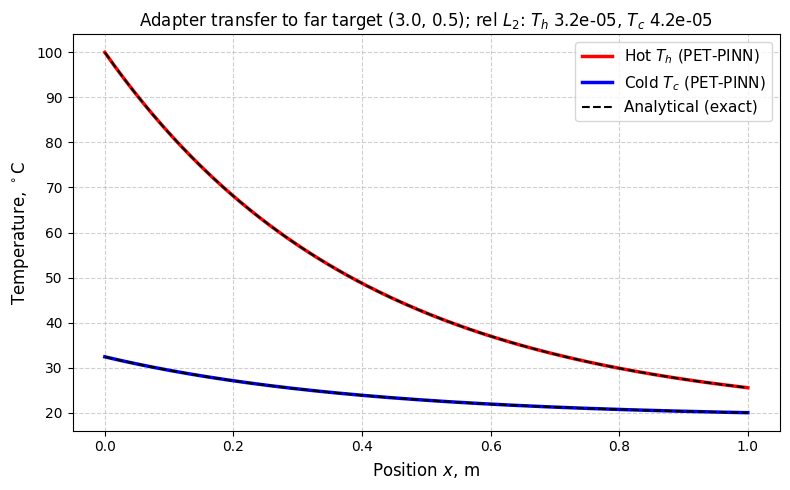

Saved: profiles_far_target.png


In [10]:
f1 = plot_rank_sweep(df, distance="far",  fname="rank_sweep_far.png")
f2 = plot_cost_bars (df, distance="far", adapter_rank=4,
                     fname="cost_comparison_far.png")
print("Saved:", f1, f2)

# Temperature profile at the far target using the r=4 adapter (visual check).
import copy as _copy
torch.manual_seed(SEED); np.random.seed(SEED)
_base = BasePINN().to(DEVICE); train(_base, *SOURCE_PT, PRE_ITERS, tag="profile-backbone")
_far = TARGETS[-1][0]
_pet = AdaptedPINN(_copy.deepcopy(_base), r=4).to(DEVICE)
train(_pet, *_far, ADAPT_ITERS, tag="profile-adapter")
_ehc, _ecc, _x, _pred, _The, _Tce = evaluate(_pet, *_far)
plt.figure(figsize=(8, 5))
plt.plot(_x, _pred[:, 0], "r-", lw=2.5, label="Hot $T_h$ (PET-PINN)")
plt.plot(_x, _pred[:, 1], "b-", lw=2.5, label="Cold $T_c$ (PET-PINN)")
plt.plot(_x, _The, "k--", lw=1.5, label="Analytical (exact)")
plt.plot(_x, _Tce, "k--", lw=1.5)
plt.xlabel("Position $x$, m", fontsize=12); plt.ylabel("Temperature, $^\\circ$C", fontsize=12)
plt.title(f"Adapter transfer to far target {_far}; rel $L_2$: "
          f"$T_h$ {_ehc:.1e}, $T_c$ {_ecc:.1e}", fontsize=12)
plt.legend(fontsize=11); plt.grid(True, ls="--", alpha=0.6); plt.tight_layout()
plt.savefig("profiles_far_target.png", dpi=300); plt.show(); plt.close()
print("Saved: profiles_far_target.png")

### Download all outputs

In [11]:
from google.colab import files
for f in ["results_raw.csv", "results_summary.csv",
          "rank_sweep_far.png", "cost_comparison_far.png",
          "profiles_far_target.png", "profiles_adapter_target.png"]:
    try:
        files.download(f)
    except Exception as e:
        print("skip", f, "->", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>